In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import (
    GaussianNB,
    MultinomialNB,
    BernoulliNB
)

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
df_bm = pd.read_csv("Data/big_mart_sales.csv")
df_bm.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
df_bm.shape

(8523, 12)

In [5]:
df_bm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [6]:
df_bm.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [7]:
df_bm.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [8]:
median_sales = df_bm["Item_Outlet_Sales"].median()

df_bm["Sales_Class"] = (
    df_bm["Item_Outlet_Sales"] >= median_sales
).astype(int)

print("Median Sales:", median_sales)

print(
    df_bm["Sales_Class"].value_counts()
)

Median Sales: 1794.331
Sales_Class
1    4266
0    4257
Name: count, dtype: int64


In [9]:
df_bm["Item_Fat_Content"] = df_bm["Item_Fat_Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
})

In [10]:
X_bm = df_bm.drop(
    columns=[
        "Item_Outlet_Sales",
        "Sales_Class"
    ]
)

y_bm = df_bm["Sales_Class"]

In [11]:
numeric_columns = X_bm.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = X_bm.select_dtypes(
    include=["object"]
).columns

print("Numerical columns:")
print(list(numeric_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']

Categorical columns:
['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']


In [12]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

X_bm_encoded = preprocessor.fit_transform(X_bm)

print("Encoded shape:", X_bm_encoded.shape)

Encoded shape: (8523, 1601)


In [13]:
X_train_bm, X_test_bm, y_train_bm, y_test_bm = train_test_split(
    X_bm_encoded,
    y_bm,
    test_size=0.20,
    random_state=42,
    stratify=y_bm
)

print("Training:", X_train_bm.shape)
print("Testing:", X_test_bm.shape)

Training: (6818, 1601)
Testing: (1705, 1601)


In [14]:
gaussian_bm = GaussianNB()

gaussian_bm.fit(
    X_train_bm,
    y_train_bm
)

y_pred_gaussian_bm = gaussian_bm.predict(
    X_test_bm
)

accuracy_gaussian_bm = accuracy_score(
    y_test_bm,
    y_pred_gaussian_bm
)

print(
    "Gaussian NB Accuracy:",
    accuracy_gaussian_bm * 100,
    "%"
)

Gaussian NB Accuracy: 74.42815249266862 %


In [15]:
print(
    classification_report(
        y_test_bm,
        y_pred_gaussian_bm,
        target_names=["Low Sales", "High Sales"]
    )
)

              precision    recall  f1-score   support

   Low Sales       0.74      0.74      0.74       852
  High Sales       0.74      0.74      0.74       853

    accuracy                           0.74      1705
   macro avg       0.74      0.74      0.74      1705
weighted avg       0.74      0.74      0.74      1705



In [16]:
scaler_bm = MinMaxScaler()

X_train_bm_scaled = scaler_bm.fit_transform(
    X_train_bm
)

X_test_bm_scaled = scaler_bm.transform(
    X_test_bm
)

In [17]:
multinomial_bm = MultinomialNB()

multinomial_bm.fit(
    X_train_bm_scaled,
    y_train_bm
)

y_pred_multinomial_bm = multinomial_bm.predict(
    X_test_bm_scaled
)

accuracy_multinomial_bm = accuracy_score(
    y_test_bm,
    y_pred_multinomial_bm
)

print(
    "Multinomial NB Accuracy:",
    accuracy_multinomial_bm * 100,
    "%"
)

Multinomial NB Accuracy: 78.00586510263929 %


In [18]:
X_train_bm_binary = (
    X_train_bm_scaled >= 0.5
).astype(int)

X_test_bm_binary = (
    X_test_bm_scaled >= 0.5
).astype(int)

In [19]:
bernoulli_bm = BernoulliNB()

bernoulli_bm.fit(
    X_train_bm_binary,
    y_train_bm
)

y_pred_bernoulli_bm = bernoulli_bm.predict(
    X_test_bm_binary
)

accuracy_bernoulli_bm = accuracy_score(
    y_test_bm,
    y_pred_bernoulli_bm
)

print(
    "Bernoulli NB Accuracy:",
    accuracy_bernoulli_bm * 100,
    "%"
)

Bernoulli NB Accuracy: 79.29618768328446 %


In [20]:
bm_results = pd.DataFrame({
    "Model": [
        "Gaussian NB",
        "Multinomial NB",
        "Bernoulli NB"
    ],
    "Accuracy": [
        accuracy_gaussian_bm,
        accuracy_multinomial_bm,
        accuracy_bernoulli_bm
    ]
})

bm_results["Accuracy (%)"] = (
    bm_results["Accuracy"] * 100
)

print(bm_results)

            Model  Accuracy  Accuracy (%)
0     Gaussian NB  0.744282     74.428152
1  Multinomial NB  0.780059     78.005865
2    Bernoulli NB  0.792962     79.296188


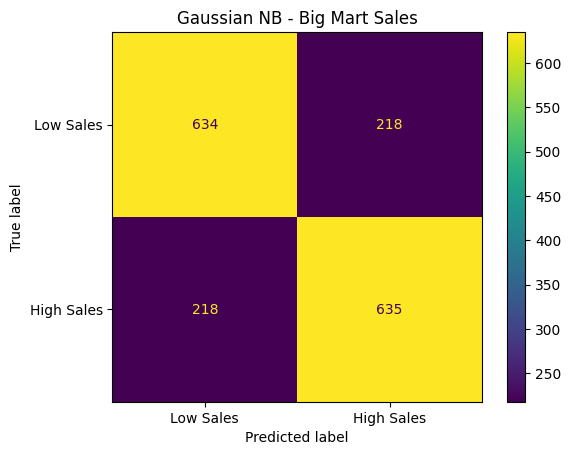

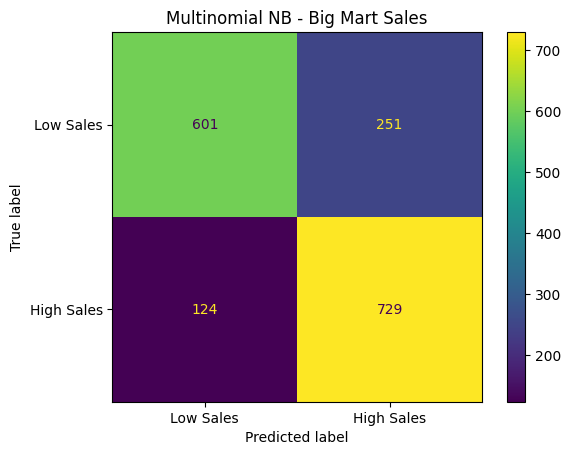

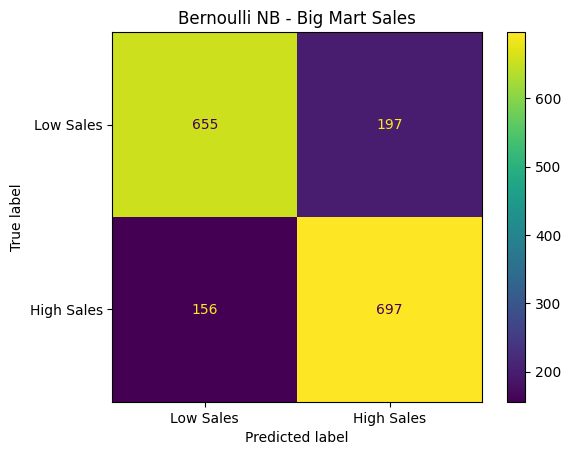

In [21]:
models_bm = {
    "Gaussian NB": y_pred_gaussian_bm,
    "Multinomial NB": y_pred_multinomial_bm,
    "Bernoulli NB": y_pred_bernoulli_bm
}

for name, predictions in models_bm.items():

    cm = confusion_matrix(
        y_test_bm,
        predictions
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Low Sales", "High Sales"]
    )

    disp.plot()
    plt.title(name + " - Big Mart Sales")
    plt.show()

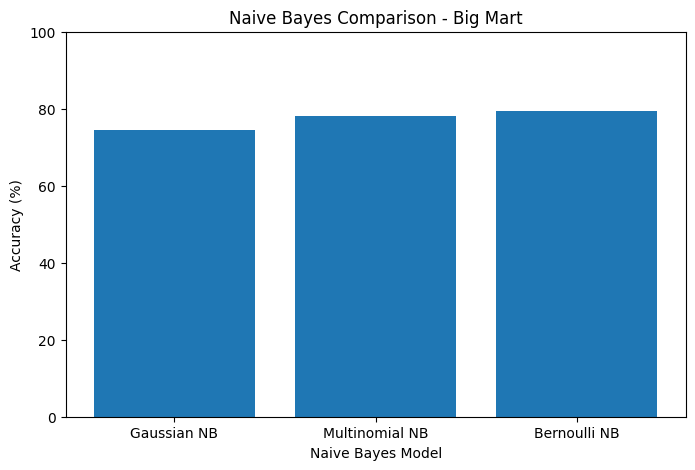

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    bm_results["Model"],
    bm_results["Accuracy (%)"]
)

plt.xlabel("Naive Bayes Model")
plt.ylabel("Accuracy (%)")
plt.title("Naive Bayes Comparison - Big Mart")

plt.ylim(0, 100)

plt.show()